# SIP Week 10: Spatio-Temporal Speech Variation

## Goal

In this notebook, we study how structured variation in speech information can be modeled.

We focus on decomposing variation into:

- global trends,
- speaker-specific differences,
- short-term environmental variation.

We use synthetic data to illustrate:

- how variation is mixed in observations,
- how it can be decomposed,
- and how this connects to Gaussian Processes.

---

## Key Idea

We model:

$$
y(s,t) = f_{global}(t) + f_{speaker}(s) + f_{env}(t,s) + \epsilon
$$

where:

- $f_{global}(t)$: shared trend across speakers
- $f_{speaker}(s)$: speaker-specific offset
- $f_{env}(t,s)$: short-term variation (environment / noise)
- $\epsilon$: observation noise

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

print("Setup complete.")

Setup complete.


## 1. Generate Synthetic Data

We create synthetic speech-information data with structured variation.

The observed signal is generated as:

$$
y(s,t) = f_{global}(t) + f_{speaker}(s) + f_{env}(t,s) + \epsilon
$$

where:

- $f_{global}(t)$: shared global trend,
- $f_{speaker}(s)$: speaker-specific offset,
- $f_{env}(t,s)$: short-term environmental variation,
- $\epsilon$: observation noise.

In [2]:
# Time axis
n_time = 100
t = np.linspace(0, 10, n_time)

# Speakers
n_speakers = 4
speakers = np.arange(n_speakers)

# Global trend: smooth shared temporal pattern
f_global = 0.4 * np.sin(t / 2) + 0.05 * t

# Speaker-specific offsets: constant differences across speakers
speaker_offsets = np.array([0.6, 0.2, -0.3, -0.7])

# Environmental variation: short-term fluctuation depending on speaker and time
f_env = np.zeros((n_speakers, n_time))

for s in speakers:
    f_env[s] = 0.15 * np.sin(2 * t + s)

# Observation noise
noise_sd = 0.05
noise = noise_sd * np.random.randn(n_speakers, n_time)

# Observed speech-information variable
Y = np.zeros((n_speakers, n_time))

for s in speakers:
    Y[s] = f_global + speaker_offsets[s] + f_env[s] + noise[s]

print("Synthetic data generated.")
print("Y shape:", Y.shape)

Synthetic data generated.
Y shape: (4, 100)


## 2. Visualize Observed Data

We now visualize the observed signal:

$$
y(s,t)
$$

Recall that the signal is composed of multiple components:

$$
y(s,t) = f_{global}(t) + f_{speaker}(s) + f_{env}(t,s) + \epsilon
$$

However, we only observe the total signal $y(s,t)$.

Different sources of variation are mixed together.


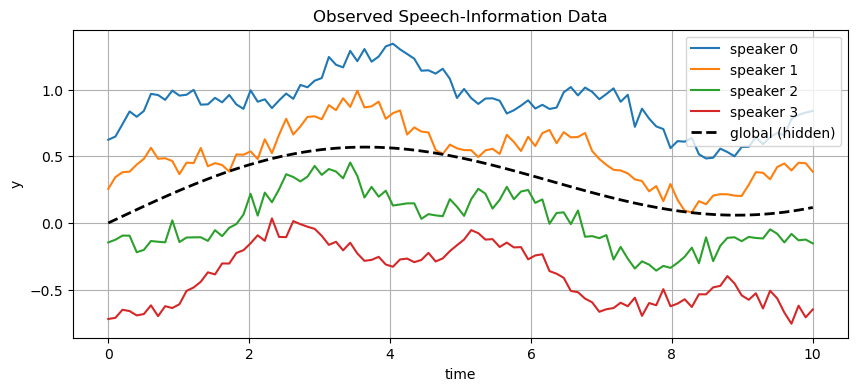

In [3]:
plt.figure()

for s in speakers:
    plt.plot(t, Y[s], label=f"speaker {s}")

# Show global trend (for reference only)
plt.plot(t, f_global, "k--", linewidth=2, label="global (hidden)")

plt.title("Observed Speech-Information Data")
plt.xlabel("time")
plt.ylabel("y")
plt.legend()
plt.show()

## 3. Global Trend

We first visualize the global component:

$$
f_{global}(t)
$$

This represents the trend shared across all speakers.

It depends only on time $t$ and captures the common structure.

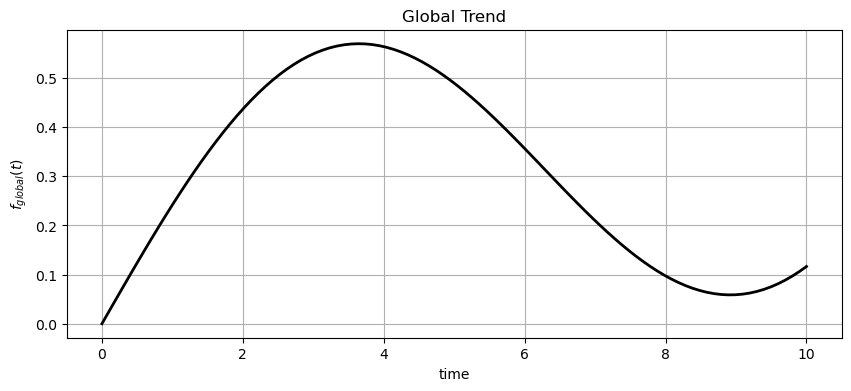

In [4]:
plt.figure()

plt.plot(t, f_global, linewidth=2, color="black")

plt.title("Global Trend")
plt.xlabel("time")
plt.ylabel(r"$f_{global}(t)$")

plt.show()

## 4. Speaker-Specific Offsets

Next, we visualize the speaker-specific component:

$$
f_{speaker}(s)
$$

This term depends only on the speaker $s$.

It does not depend on time $t$.

Therefore, it appears as a constant baseline shift for each speaker.

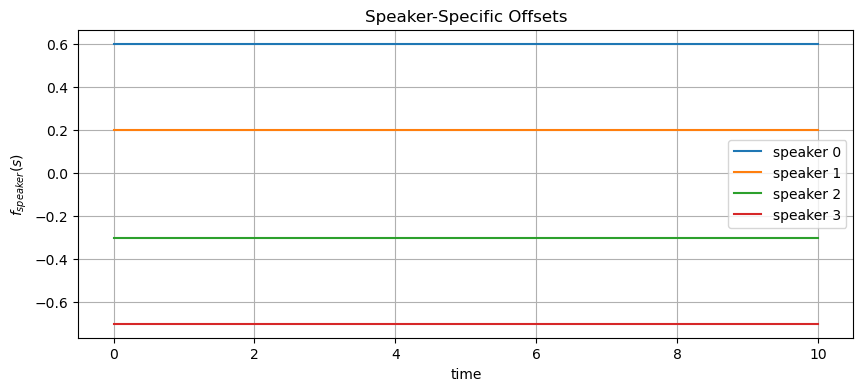

In [5]:
plt.figure()

for s in speakers:
    offset_line = np.ones_like(t) * speaker_offsets[s]
    plt.plot(t, offset_line, label=f"speaker {s}")

plt.title("Speaker-Specific Offsets")
plt.xlabel("time")
plt.ylabel(r"$f_{speaker}(s)$")
plt.legend()
plt.show()

(*) Each horizontal line represents a speaker-specific baseline.
It does not change over time.
Speaker 0 has a higher baseline, while speaker 3 has a lower baseline.
This is different from ageing, which changes over time.

## 5. Environmental Variation

Next, we visualize the environmental component:

$$
f_{env}(t,s)
$$

This term depends on both time $t$ and speaker $s$.

It represents short-term fluctuations, such as:

- recording condition,
- background noise,
- channel variation,
- temporary speaking condition.

Unlike $f_{speaker}(s)$, this component changes over time.

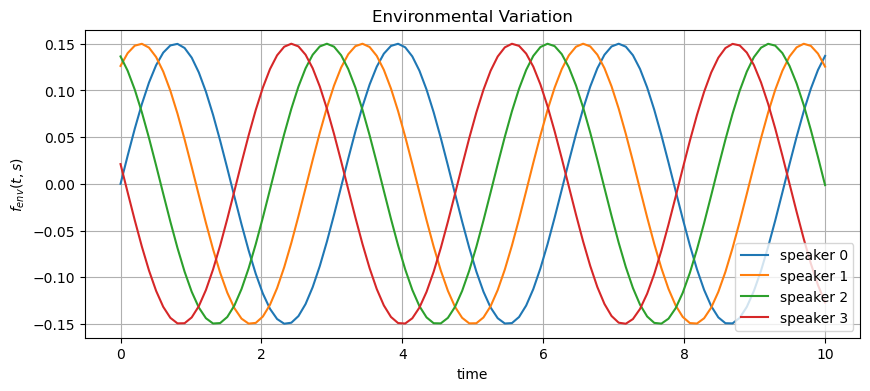

In [6]:
plt.figure()

for s in speakers:
    plt.plot(t, f_env[s], label=f"speaker {s}")

plt.title("Environmental Variation")
plt.xlabel("time")
plt.ylabel(r"$f_{env}(t,s)$")
plt.legend()
plt.show()

(*) This component changes over time.
It represents short-term variation, not ageing.

## 6. Compare All Components

We now compare the three components:

$$
y(s,t) = f_{global}(t) + f_{speaker}(s) + f_{env}(t,s)
$$

Each component has a different role:

- $f_{global}(t)$: shared trend (time-dependent)
- $f_{speaker}(s)$: constant offset (speaker-dependent)
- $f_{env}(t,s)$: short-term variation (time + speaker)

Understanding these differences is the key to hierarchical modeling.

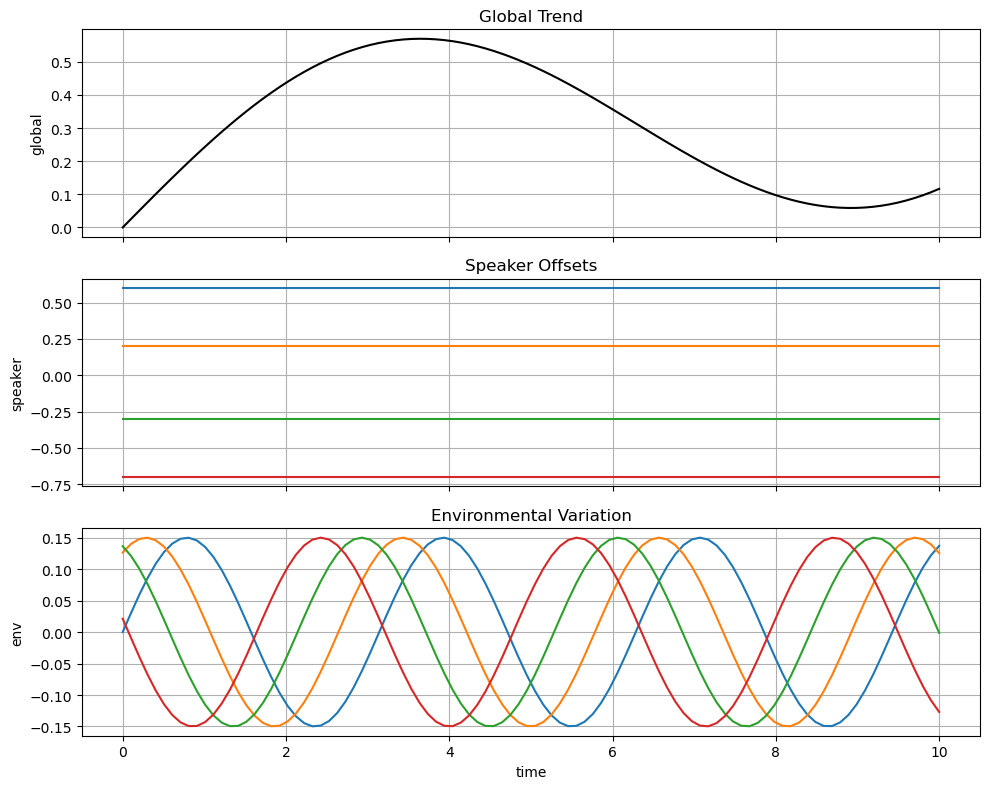

In [7]:
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 8))

# Global
axes[0].plot(t, f_global, color="black")
axes[0].set_title("Global Trend")
axes[0].set_ylabel("global")

# Speaker offsets
for s in speakers:
    axes[1].plot(t, np.ones_like(t) * speaker_offsets[s])
axes[1].set_title("Speaker Offsets")
axes[1].set_ylabel("speaker")

# Environmental variation
for s in speakers:
    axes[2].plot(t, f_env[s])
axes[2].set_title("Environmental Variation")
axes[2].set_ylabel("env")

axes[2].set_xlabel("time")

plt.tight_layout()
plt.show()

## 7. From Decomposition to Gaussian Process

So far, we used the true components.

In real data, we do not know:

- $f_{global}(t)$
- $f_{speaker}(s)$
- $f_{env}(t,s)$

We only observe:

$$
y(s,t)
$$

The question is:

Can we recover these components from data?

Gaussian Processes provide a way to do this.

In [8]:
# placeholder
print("Next: we will use Gaussian Processes to infer the components.")

Next: we will use Gaussian Processes to infer the components.


## ８. Gaussian Process Decomposition

Now we use Gaussian Process regression to infer the latent components.

We assume:

$$
y = f_{global} + f_{speaker} + f_{env} + \epsilon
$$

with independent GP priors:

$$
f_{global} \sim GP(0, K_{global})
$$

$$
f_{speaker} \sim GP(0, K_{speaker})
$$

$$
f_{env} \sim GP(0, K_{env})
$$

Then:

$$
K_{total} = K_{global} + K_{speaker} + K_{env}
$$

The posterior mean of each component is:

$$
E[f_{global} \mid y]
=
K_{global}
(K_{total} + \sigma^2 I)^{-1} y
$$

$$
E[f_{speaker} \mid y]
=
K_{speaker}
(K_{total} + \sigma^2 I)^{-1} y
$$

$$
E[f_{env} \mid y]
=
K_{env}
(K_{total} + \sigma^2 I)^{-1} y
$$

This is exact for independent Gaussian components with Gaussian noise.

In [9]:
# Flatten data into one vector
# Each observation corresponds to a pair (speaker, time)

speaker_index = []
time_index = []
y_obs = []

for s in speakers:
    for i, ti in enumerate(t):
        speaker_index.append(s)
        time_index.append(ti)
        y_obs.append(Y[s, i])

speaker_index = np.array(speaker_index)
time_index = np.array(time_index)
y_obs = np.array(y_obs)

N = len(y_obs)

print("Number of observations:", N)
print("y_obs shape:", y_obs.shape)

Number of observations: 400
y_obs shape: (400,)


In [10]:
def squared_exponential_kernel(x1, x2, length_scale=1.0, variance=1.0):
    """
    Squared exponential kernel for one-dimensional inputs.
    """
    x1 = np.asarray(x1)[:, None]
    x2 = np.asarray(x2)[None, :]
    return variance * np.exp(-0.5 * ((x1 - x2) / length_scale) ** 2)


def speaker_kernel(s1, s2, variance=1.0):
    """
    Simple speaker kernel:
    same speaker -> variance
    different speaker -> 0
    """
    s1 = np.asarray(s1)[:, None]
    s2 = np.asarray(s2)[None, :]
    return variance * (s1 == s2).astype(float)

In [11]:
# Construct component kernels

# Global trend: smooth over time and shared across speakers
K_global = squared_exponential_kernel(
    time_index,
    time_index,
    length_scale=3.0,
    variance=0.5
)

# Speaker offset: depends only on speaker identity
K_speaker = speaker_kernel(
    speaker_index,
    speaker_index,
    variance=0.4
)

# Environmental variation: short time-scale, speaker-specific
K_env_time = squared_exponential_kernel(
    time_index,
    time_index,
    length_scale=0.5,
    variance=0.2
)

K_env_speaker = speaker_kernel(
    speaker_index,
    speaker_index,
    variance=1.0
)

K_env = K_env_time * K_env_speaker

# Observation noise
sigma2 = noise_sd ** 2

K_total = K_global + K_speaker + K_env
K_y = K_total + sigma2 * np.eye(N)

print("K_global:", K_global.shape)
print("K_speaker:", K_speaker.shape)
print("K_env:", K_env.shape)
print("K_y:", K_y.shape)

K_global: (400, 400)
K_speaker: (400, 400)
K_env: (400, 400)
K_y: (400, 400)


In [12]:
# GP posterior component means

# Solve (K_total + sigma^2 I) alpha = y
alpha = np.linalg.solve(K_y, y_obs)

f_global_post = K_global @ alpha
f_speaker_post = K_speaker @ alpha
f_env_post = K_env @ alpha

# Reshape back to speaker x time format
f_global_post_matrix = f_global_post.reshape(n_speakers, n_time)
f_speaker_post_matrix = f_speaker_post.reshape(n_speakers, n_time)
f_env_post_matrix = f_env_post.reshape(n_speakers, n_time)

print("Posterior component means computed.")

Posterior component means computed.


## 9. Visualize GP-Decomposed Components

We now visualize the posterior mean of each component.

The GP decomposition gives:

$$
E[f_{global} \mid y]
$$

$$
E[f_{speaker} \mid y]
$$

$$
E[f_{env} \mid y]
$$

We compare these inferred components with the true components used to generate the synthetic data.

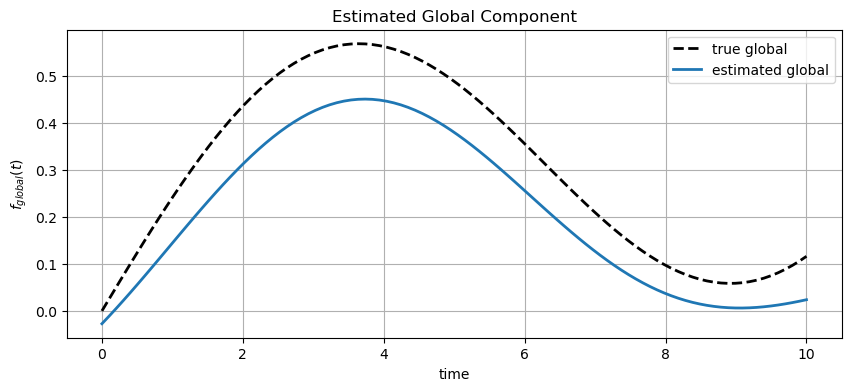

In [13]:
# Global component:
# The posterior global component is repeated for each speaker.
# We average over speakers for visualization.

f_global_est = f_global_post_matrix.mean(axis=0)

plt.figure()
plt.plot(t, f_global, "k--", linewidth=2, label="true global")
plt.plot(t, f_global_est, linewidth=2, label="estimated global")

plt.title("Estimated Global Component")
plt.xlabel("time")
plt.ylabel(r"$f_{global}(t)$")
plt.legend()
plt.show()

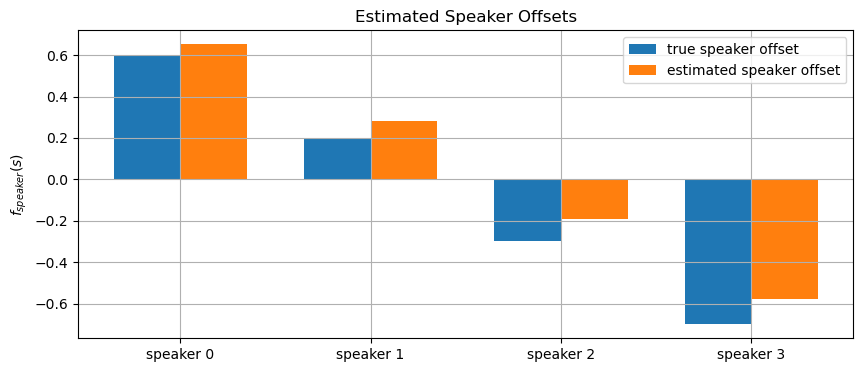

In [14]:
# Speaker component:
# The posterior speaker component is constant-like for each speaker.
# We average over time to estimate one offset per speaker.

f_speaker_est = f_speaker_post_matrix.mean(axis=1)

plt.figure()

x_pos = np.arange(n_speakers)
width = 0.35

plt.bar(x_pos - width/2, speaker_offsets, width, label="true speaker offset")
plt.bar(x_pos + width/2, f_speaker_est, width, label="estimated speaker offset")

plt.xticks(x_pos, [f"speaker {s}" for s in speakers])
plt.ylabel(r"$f_{speaker}(s)$")
plt.title("Estimated Speaker Offsets")
plt.legend()
plt.show()

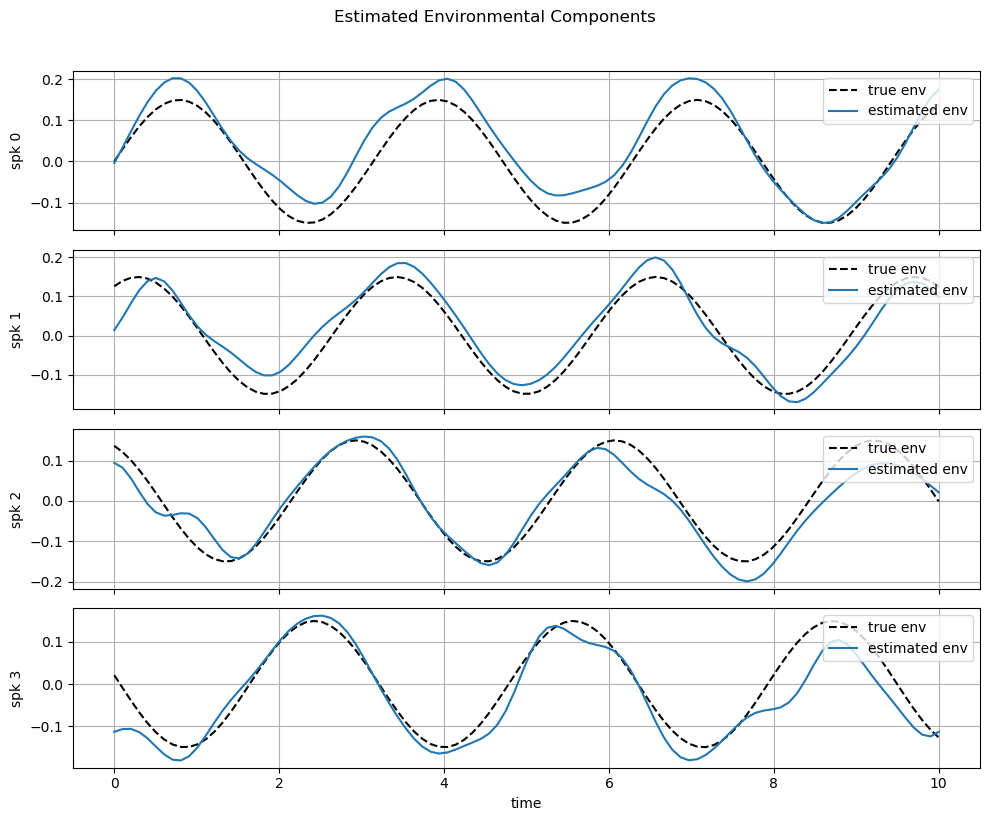

In [15]:
# Environmental component:
# Compare true and estimated environmental variation for each speaker.

fig, axes = plt.subplots(n_speakers, 1, sharex=True, figsize=(10, 8))

for s in speakers:
    axes[s].plot(t, f_env[s], "k--", label="true env")
    axes[s].plot(t, f_env_post_matrix[s], label="estimated env")
    axes[s].set_ylabel(f"spk {s}")
    axes[s].legend(loc="upper right")

axes[-1].set_xlabel("time")
fig.suptitle("Estimated Environmental Components", y=1.02)
plt.tight_layout()
plt.show()

(*) The model does not observe these components directly.
It recovers them through the covariance structure.

In [16]:
# Posterior variance for the global component

# Compute inverse once (already used for posterior mean)
K_inv = np.linalg.inv(K_y)

# Posterior covariance of the global component
Cov_global_post = K_global - K_global @ K_inv @ K_global

# Extract diagonal (variance at each point)
var_global = np.diag(Cov_global_post)

# Reshape to (n_speakers, n_time)
var_global_matrix = var_global.reshape(n_speakers, n_time)

# Since the global component is shared across speakers,
# we average the variance across speakers for visualization
var_global_est = var_global_matrix.mean(axis=0)

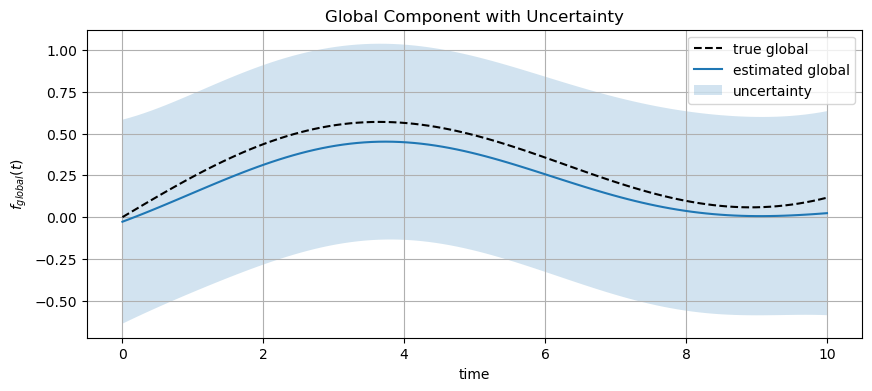

In [17]:
std_global = np.sqrt(var_global_est)

plt.figure()

plt.plot(t, f_global, "k--", label="true global")
plt.plot(t, f_global_est, label="estimated global")

plt.fill_between(
    t,
    f_global_est - 2 * std_global,
    f_global_est + 2 * std_global,
    alpha=0.2,
    label="uncertainty"
)

plt.title("Global Component with Uncertainty")
plt.xlabel("time")
plt.ylabel(r"$f_{global}(t)$")
plt.legend()
plt.show()

## 10. What Did We Learn?

From this exercise, we learned:

- Observed data mixes multiple sources of variation.
- Gaussian Processes can recover structured components.
- Different kernels separate different types of variation.
- We can extract interpretable components from data.

Key insight:

$$
\text{Model structure + kernel design} \Rightarrow \text{interpretable decomposition}
$$

In [18]:
# Reconstruction check
# Make sure these posterior components were computed using the current y_obs.

y_reconstructed = f_global_post + f_speaker_post + f_env_post

print("y_reconstructed shape:", y_reconstructed.shape)
print("y_obs shape:", y_obs.shape)

assert y_reconstructed.shape == y_obs.shape, (
    "Shape mismatch: please rerun the GP posterior cells after redefining y_obs."
)

error = np.mean((y_reconstructed - y_obs) ** 2)

print("Reconstruction error:", error)

y_reconstructed shape: (400,)
y_obs shape: (400,)
Reconstruction error: 0.0017485641460054204
